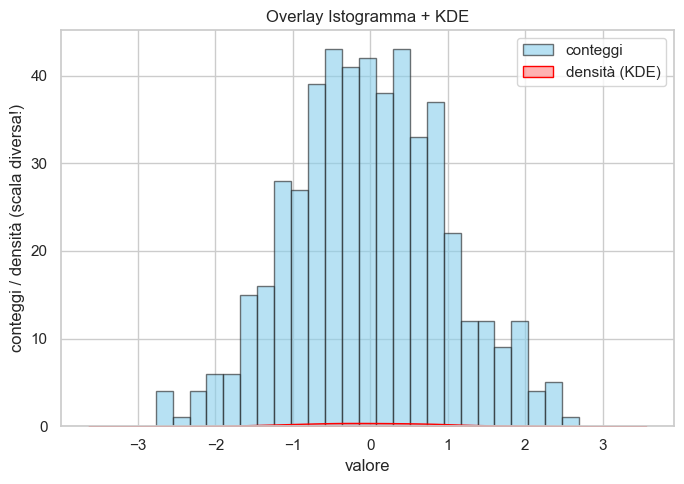

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")  # estetica seaborn, ma controllo finale su Matplotlib
np.random.seed(0)

data = np.random.normal(0, 1, 500)

fig, ax = plt.subplots(figsize=(7, 5))

# layer 1: istogramma (conteggi)
ax.hist(data, bins=25, color="skyblue", alpha=0.6, edgecolor="k", label="conteggi")

# layer 2: KDE (densità) disegnata da seaborn sullo stesso ax
sns.kdeplot(data, ax=ax, color="red", fill=True, alpha=0.3, label="densità (KDE)")

ax.set_title("Overlay Istogramma + KDE")
ax.set_xlabel("valore")
ax.set_ylabel("conteggi / densità (scala diversa!)")
ax.legend()

plt.tight_layout()
plt.show()



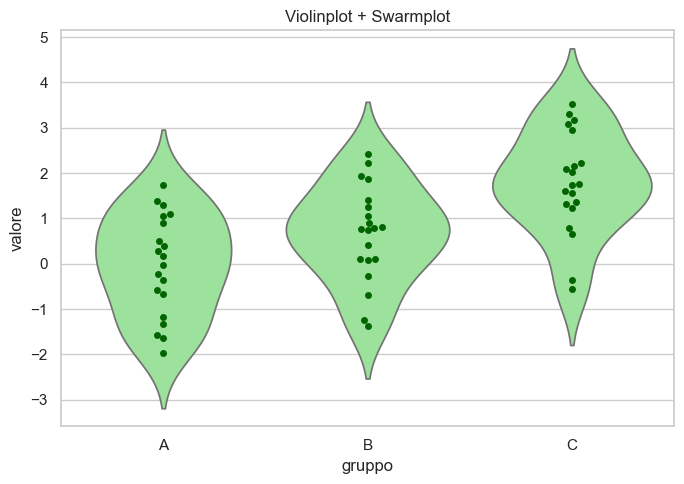

In [2]:
# - ESEMPIO 2 — Categoriale: Violin + Swarm

df = pd.DataFrame({
    "gruppo": np.repeat(["A", "B", "C"], 20),
    "valore": np.random.randn(60) + np.repeat([0, 1, 2], 20)
})

fig, ax = plt.subplots(figsize=(7, 5))

# layer 1: violin (forma distribuzione)
sns.violinplot(
    data=df, x="gruppo", y="valore",
    ax=ax, inner=None, color="lightgreen"
)

# layer 2: swarm (singoli punti)
sns.swarmplot(
    data=df, x="gruppo", y="valore",
    ax=ax, color="darkgreen", size=5
)

ax.set_title("Violinplot + Swarmplot")
ax.set_xlabel("gruppo")
ax.set_ylabel("valore")

plt.tight_layout()
plt.show()

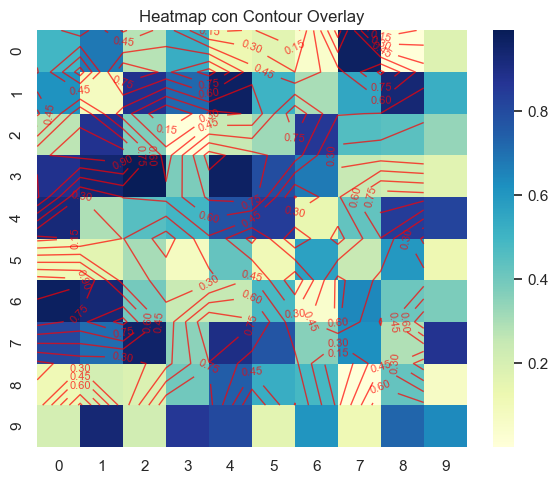

In [3]:
# - ESEMPIO 3 — Heatmap + Contour Overlay

Z = np.random.rand(10, 10)

fig, ax = plt.subplots(figsize=(6, 5))

# layer 1: heatmap
sns.heatmap(Z, ax=ax, cmap="YlGnBu", cbar=True)

# layer 2: contour Matplotlib
contour = ax.contour(Z, colors="red", linewidths=1, alpha=0.7)
ax.clabel(contour, inline=True, fontsize=8)

ax.set_title("Heatmap con Contour Overlay")

plt.tight_layout()
plt.show()



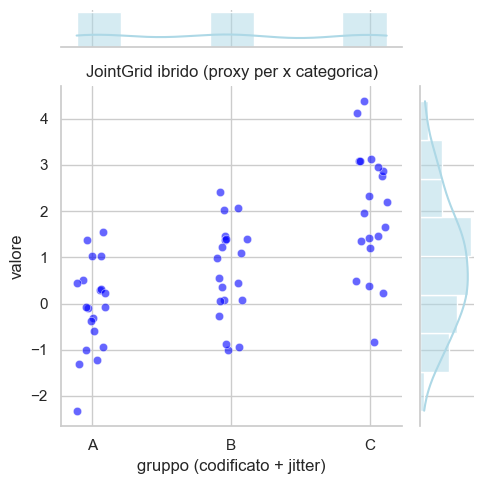

In [4]:
# - ESEMPIO 4A — JointGrid “come nel prompt” (x categorica)

# riuso df dell'Esempio 2
df = pd.DataFrame({
    "gruppo": np.repeat(["A", "B", "C"], 20),
    "valore": np.random.randn(60) + np.repeat([0, 1, 2], 20)
})

# mappo categorie in numeri e aggiungo jitter
map_g = {"A": 0, "B": 1, "C": 2}
df["gruppo_num"] = df["gruppo"].map(map_g)
df["gruppo_jitter"] = df["gruppo_num"] + np.random.uniform(-0.12, 0.12, size=len(df))

g = sns.JointGrid(data=df, x="gruppo_jitter", y="valore", height=5)

# joint: scatter
g.plot_joint(sns.scatterplot, color="blue", alpha=0.6)

# margini: istogramma + kde
g.plot_marginals(sns.histplot, kde=True, color="lightblue")

# rifiniture Matplotlib sul joint axes
g.ax_joint.set_title("JointGrid ibrido (proxy per x categorica)")
g.ax_joint.set_xlabel("gruppo (codificato + jitter)")
g.ax_joint.set_xticks([0, 1, 2])
g.ax_joint.set_xticklabels(["A", "B", "C"])

plt.tight_layout()
plt.show()




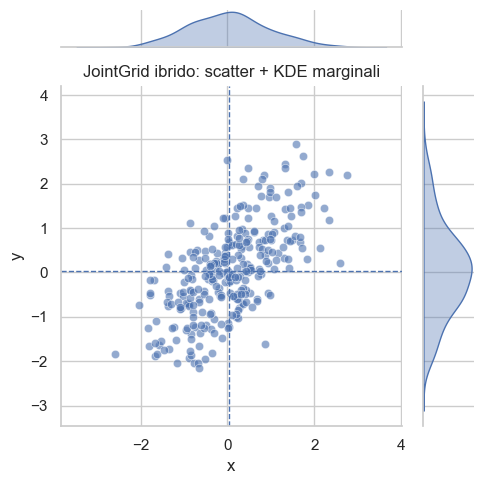

In [5]:
# - ESEMPIO 4B — JointGrid “sensato” (x e y numeriche)

x = np.random.normal(0, 1, 300)
y = 0.7 * x + np.random.normal(0, 0.8, 300)
df_xy = pd.DataFrame({"x": x, "y": y})

g = sns.JointGrid(data=df_xy, x="x", y="y", height=5)

g.plot_joint(sns.scatterplot, alpha=0.6)
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.35)

g.ax_joint.set_title("JointGrid ibrido: scatter + KDE marginali")
g.ax_joint.axhline(df_xy["y"].mean(), linestyle="--", linewidth=1)
g.ax_joint.axvline(df_xy["x"].mean(), linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()


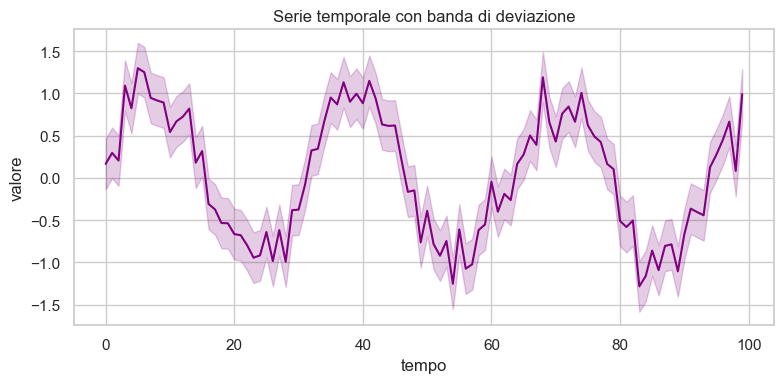

In [6]:
# - ESEMPIO 5 — Serie temporale con banda (± deviazione fissa)

t = np.arange(0, 100)
values = np.sin(t / 5) + np.random.normal(0, 0.2, 100)
std_dev = 0.3

fig, ax = plt.subplots(figsize=(8, 4))

# layer 1: linea (seaborn su ax)
sns.lineplot(x=t, y=values, ax=ax, color="purple")

# layer 2: banda Matplotlib
ax.fill_between(t, values - std_dev, values + std_dev, color="purple", alpha=0.2)

ax.set_title("Serie temporale con banda di deviazione")
ax.set_xlabel("tempo")
ax.set_ylabel("valore")

plt.tight_layout()
plt.show()
